# Data Science Project: Big Mart Sales Analysis

In [1]:
# Load in the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Load in our dataset from Kaggle in a .csv format

In [2]:
# Read in the data from our csv file containing item and outlet sales information
df_groceries = pd.read_csv('../data/big_mart_sales.csv', delimiter=',', header='infer')

# Report information regarding the dataset

df_groceries.info()

# Count unique outlets
n_outlets = df_groceries['Outlet_Identifier'].nunique()
print(f"Number of unique outlets: {n_outlets}")

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB
Number of unique outlets: 10


In [3]:
# Show the first 5 rows of the dataset
df_groceries.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## 1. Handling empty data entries

In [4]:
# Let's identify the columns that contain missing values or entries containing Nan or None
missing_values = df_groceries.isnull().sum()
print(missing_values)

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


### Missing data

Item weight and outlet size are missing for some rows. To take care of item weight lets use the median for item's of the same type as a placeholder. For outlet size let's use the mode for outlets with the same type since the data is stored as strings.

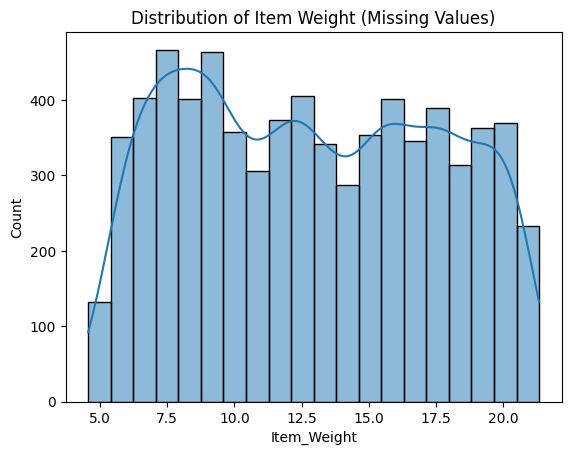

In [5]:
# Visualise the Item Weight data with Seaborn and Matplotlib while data is missing
sns.histplot(df_groceries["Item_Weight"], kde=True)
plt.title("Distribution of Item Weight (Missing Values)")
plt.show()


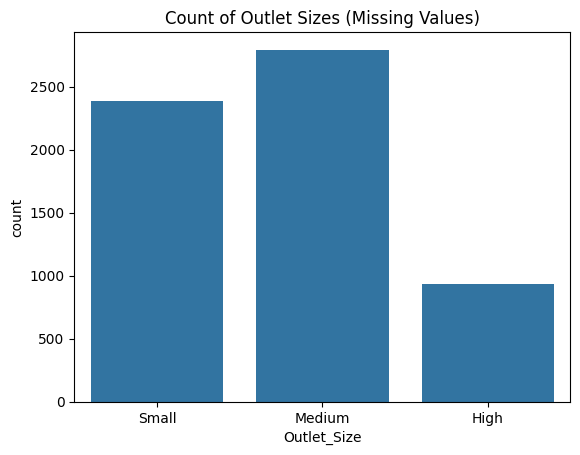

In [6]:
# Visualise the missing Outlet Size data with Seaborn and Matplotlib

sns.countplot(data=df_groceries, x="Outlet_Size", order=["Small", "Medium", "High"])
plt.title("Count of Outlet Sizes (Missing Values)")
plt.show()

In [7]:
# Item Weight
df_groceries['Item_Weight_filled'] = df_groceries['Item_Weight'].fillna(df_groceries.groupby("Item_Type")["Item_Weight"].transform("median"))

In [8]:
# Outlet Size
# Fill missing outlet sizes with the mode of the outlet size for matching outlet types
# Use a lamda function to check if the mode is empty before trying to access the first element, to avoid errors in case of empty groups
df_groceries["Outlet_Size_filled"] = df_groceries["Outlet_Size"].fillna(
    df_groceries.groupby("Outlet_Type")["Outlet_Size"]
      .transform(lambda x: x.mode()[0] if not x.mode().empty else x)
)

In [9]:
# Create outlet-level DataFrame (one row per outlet, 10 unique outlets)
df_outlets = df_groceries.drop_duplicates(subset='Outlet_Identifier').reset_index(drop=True)

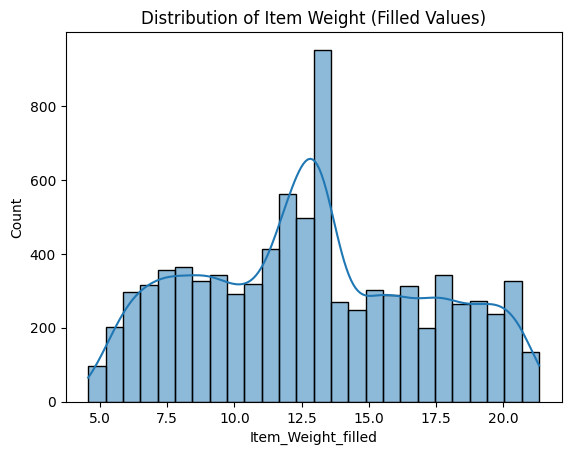

In [10]:
# Visualise the Item Weight data with Seaborn and Matplotlib after filling data
sns.histplot(df_groceries["Item_Weight_filled"], kde=True)
plt.title("Distribution of Item Weight (Filled Values)")
plt.show()

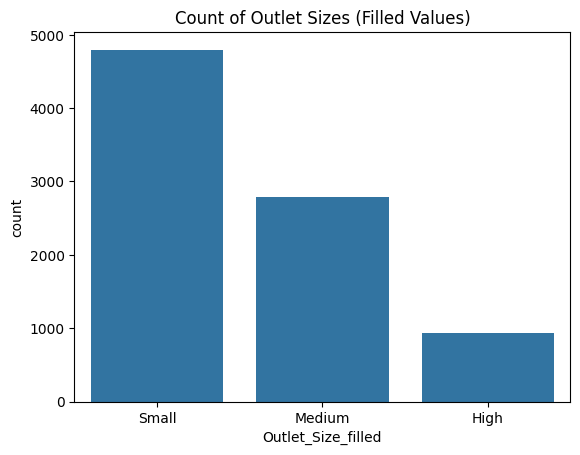

In [11]:
# Visualise the missing Outlet Size data with Seaborn and Matplotlib

sns.countplot(data=df_groceries, x="Outlet_Size_filled", order=["Small", "Medium", "High"])
plt.title("Count of Outlet Sizes (Filled Values)")
plt.show()

### Thoughts on empty data and methods to insert replacement values

The addition of data points equal to the median of items with the same type succeeded in maintaining a normal distribution, but did introduce an artificial peak around 13. This may become relevant if item weight data is used to inform models on sales data in the future. It may be more effective, in that case, to map item weight values to reflect the distribution of the present data.

Classifications of small outlet_sizes were introduced after filling in the empty data entries. This now makes small the most common outlet size. Similarly to item weight, this artificial increase needs to be considered if using outlet_size as a factor in future predictions of sales and revenue.

## 2. Exploratory Data Analysis

Our analysis is primarily concerned with the following categories:

1. Item Sales (`Item_Outlet_Sales`)
2. Item Revenue (`Item_MRP` * `Item_Outlet_Sales`)
3. Outlet Information (as it relates to sales performance)
    - Size (`Outlet_Size`)
    - Age (Current Year - `Outlet_Establishment_Year`)
    - Location (`Outlet_Location_Type`)
    - Type (`Outlet_Type`)

Therefore, we want to visualise data relevant to our variables of interest.

### Seaborn Analysis

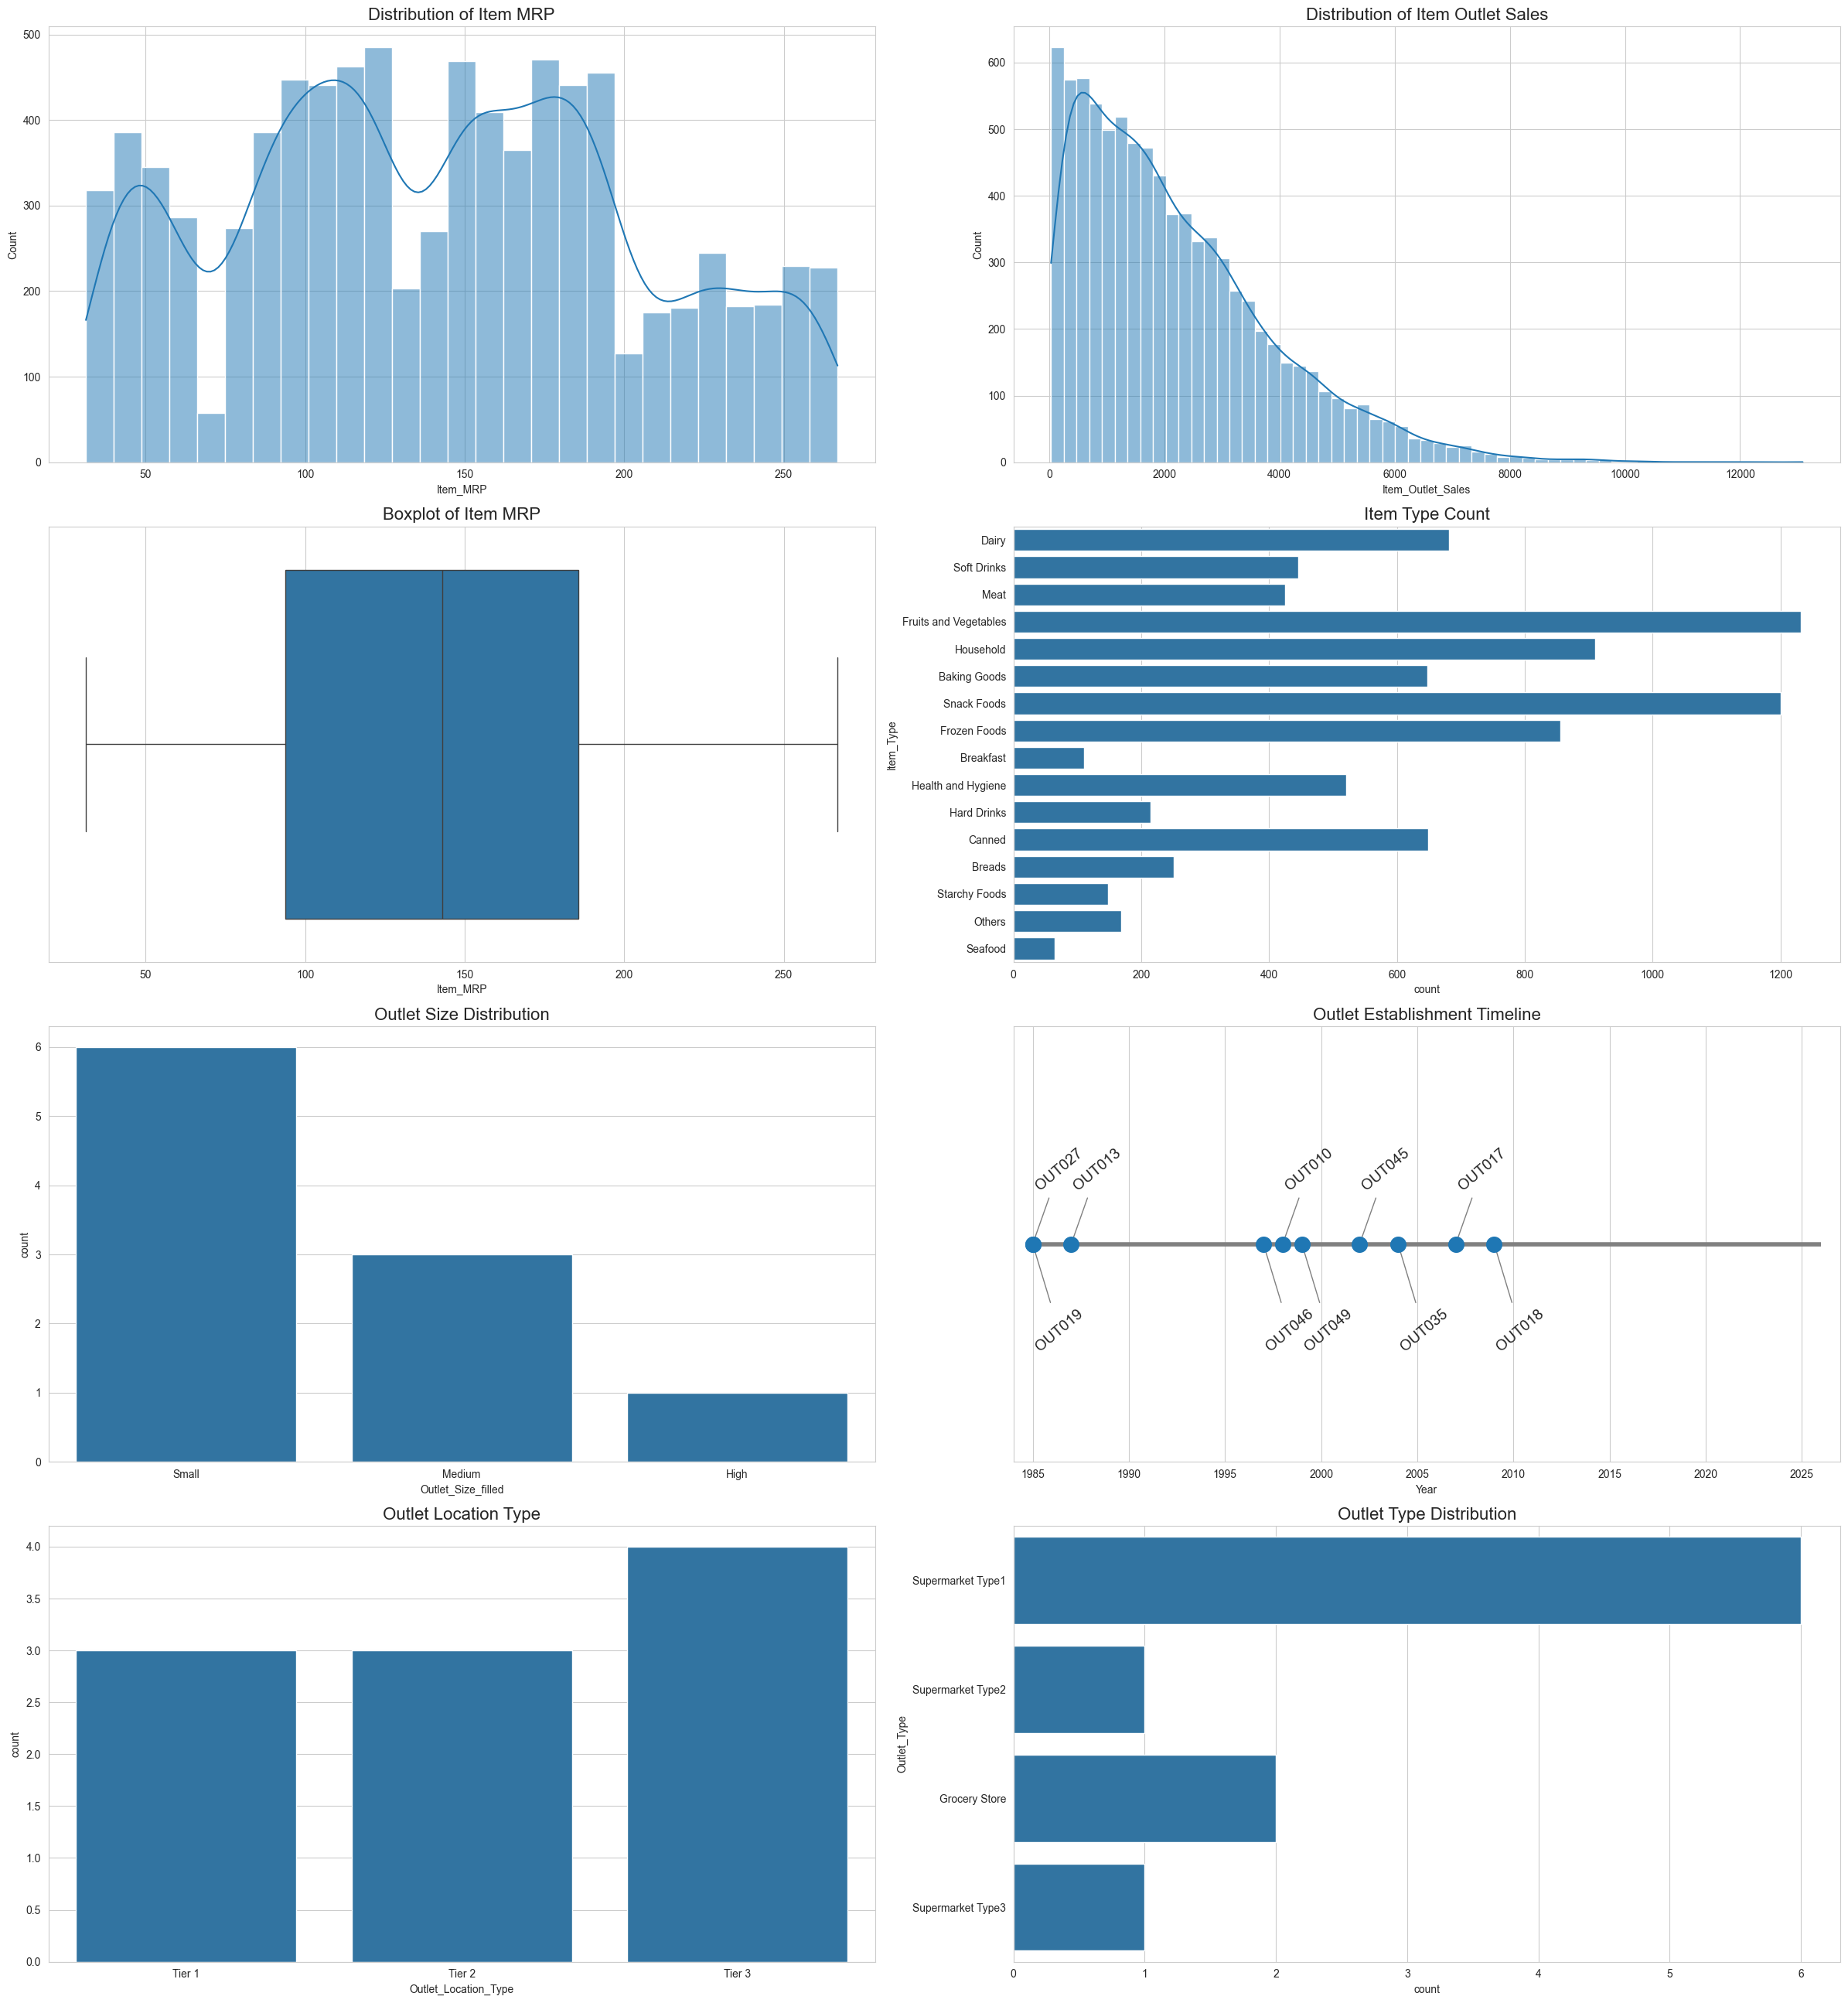

In [12]:
sns.set_style("whitegrid")

# Create a 4x2 grid of subplots for visualizations
fig, axes = plt.subplots(4, 2, figsize=(24, 26))
axes = axes.flatten()

## Visualise the distribution of Item MRP and Item Outlet Sales, and the boxplot of Item MRP, and the count of Item Type

# 1 Distribution of Item_MRP
sns.histplot(df_groceries['Item_MRP'], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Item MRP", fontsize=16)

# 2 Distribution of Sales
sns.histplot(df_groceries['Item_Outlet_Sales'], kde=True, ax=axes[1])
axes[1].set_title("Distribution of Item Outlet Sales", fontsize=16)

# 3 Boxplot MRP
sns.boxplot(x=df_groceries['Item_MRP'], ax=axes[2])
axes[2].set_title("Boxplot of Item MRP", fontsize=16)

# 4 Item Type count
sns.countplot(y='Item_Type', data=df_groceries, ax=axes[3])
axes[3].set_title("Item Type Count", fontsize=16)

## Outlet distribution plots — based on 10 unique outlets (deduplicated by Outlet_Identifier)

# 5 Outlet Size distribution
sns.countplot(x='Outlet_Size_filled', data=df_outlets, order=['Small', 'Medium', 'High'], ax=axes[4])
axes[4].set_title("Outlet Size Distribution", fontsize=16)

# 6 Outlet Establishment Year — timeline from first outlet to 2026
years = df_outlets['Outlet_Establishment_Year'].values
outlets = df_outlets['Outlet_Identifier'].values
sorted_idx = years.argsort()
years, outlets = years[sorted_idx], outlets[sorted_idx]

axes[5].hlines(0, years.min(), 2026, colors='gray', linewidth=4)
axes[5].scatter(years, [0]*len(years), s=200, zorder=5)
for i, (year, outlet) in enumerate(zip(years, outlets)):
    offset = 50 if i % 2 == 0 else -100
    axes[5].annotate(outlet, xy=(year, 0), xytext=(0, offset),
                     textcoords="offset points",
                     rotation=40, ha='left', fontsize=14,
                     arrowprops=dict(arrowstyle='-', color='gray', lw=1))
axes[5].set_xlim(years.min() - 1, 2027)
axes[5].set_yticks([])
axes[5].set_title("Outlet Establishment Timeline", fontsize=16)
axes[5].set_xlabel("Year")

# 7 Outlet Location Type distribution
sns.countplot(x='Outlet_Location_Type', data=df_outlets, order=['Tier 1', 'Tier 2', 'Tier 3'], ax=axes[6])
axes[6].set_title("Outlet Location Type", fontsize=16)

# 8 Outlet Type distribution
sns.countplot(y='Outlet_Type', data=df_outlets, ax=axes[7])
axes[7].set_title("Outlet Type Distribution", fontsize=16)

plt.tight_layout()
plt.show()


### We may also benefit from visualisations of relationships between different parameters

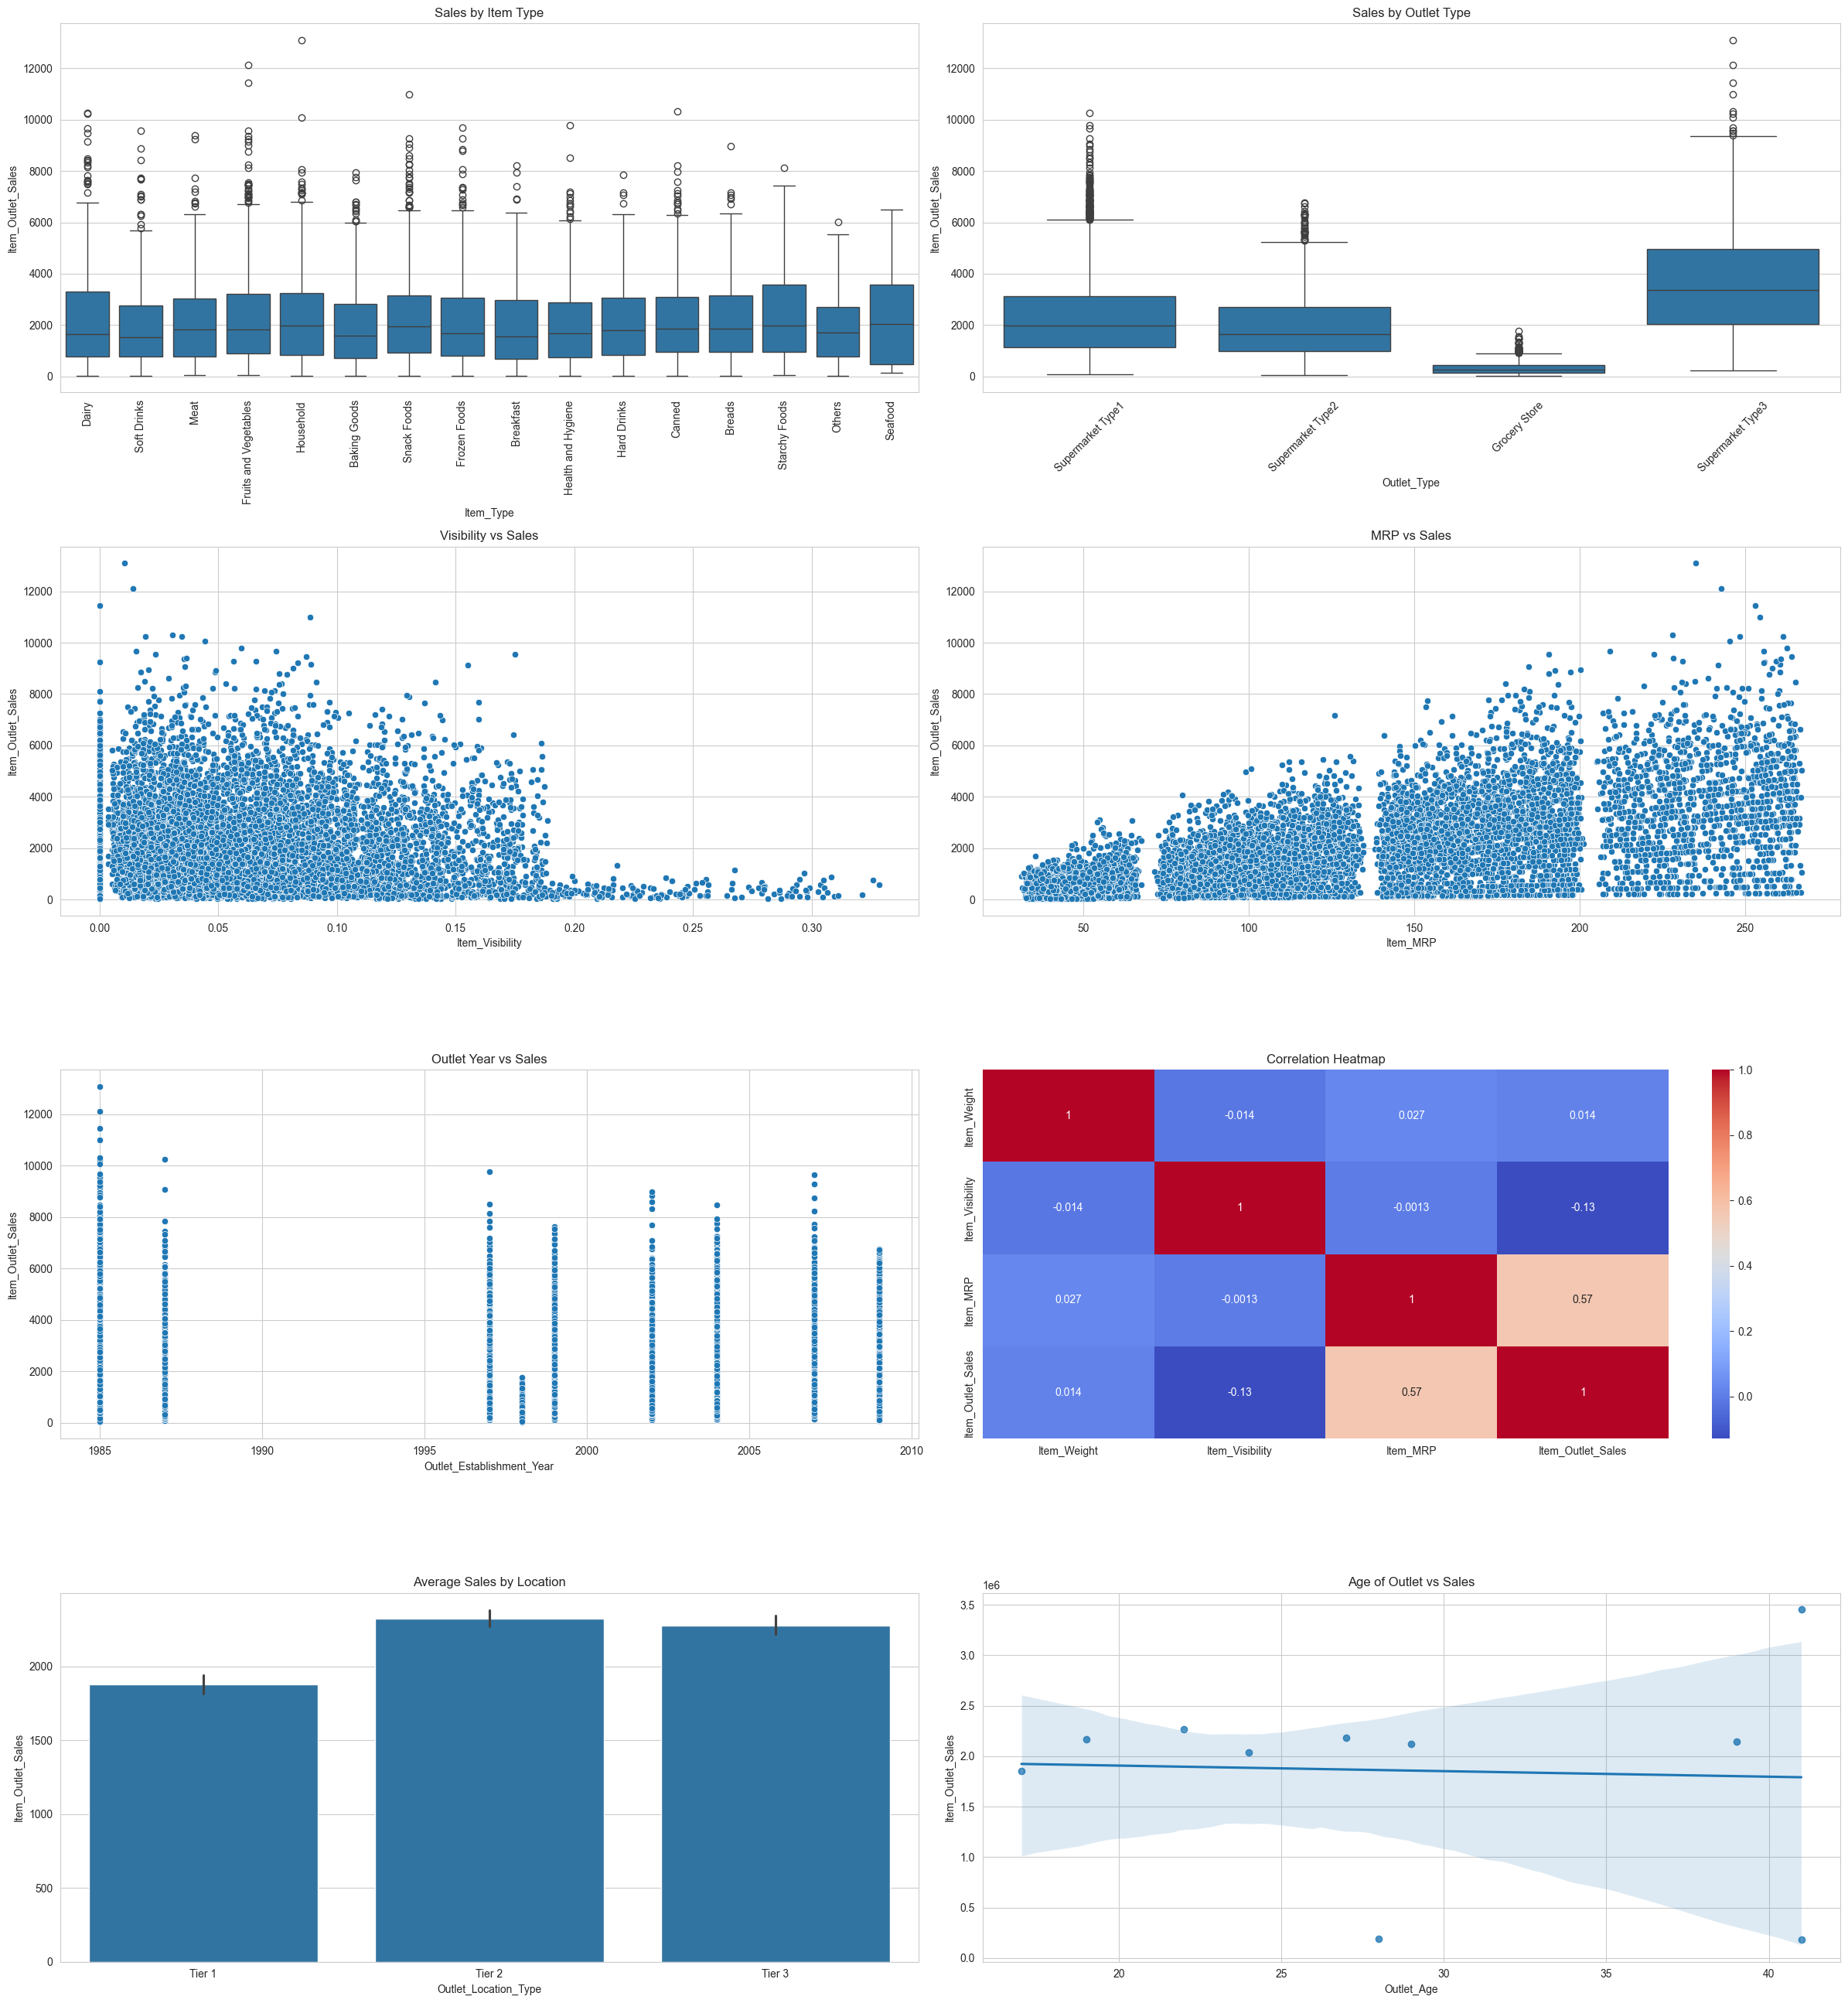

In [13]:
sns.set_style("whitegrid")

# Create a 4x2 grid of subplots for visualizations
fig, axes = plt.subplots(4, 2, figsize=(24, 26))
axes = axes.flatten()

# 9 Item Type vs Sales
sns.boxplot(x='Item_Type', y='Item_Outlet_Sales', data=df_groceries, ax=axes[0])
axes[0].tick_params(axis='x', rotation=90)
axes[0].set_title("Sales by Item Type")

# 10 Outlet Type vs Sales
sns.boxplot(x='Outlet_Type', y='Item_Outlet_Sales', data=df_groceries, ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title("Sales by Outlet Type")

# 11 Visibility vs Sales
sns.scatterplot(x='Item_Visibility', y='Item_Outlet_Sales', data=df_groceries, ax=axes[2])
axes[2].set_title("Visibility vs Sales")

# 12 MRP vs Sales
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=df_groceries, ax=axes[3])
axes[3].set_title("MRP vs Sales")

# 13 Establishment Year vs Sales
sns.scatterplot(x='Outlet_Establishment_Year', y='Item_Outlet_Sales', data=df_groceries, ax=axes[4])
axes[4].set_title("Outlet Year vs Sales")

# 14 Correlation Heatmap
corr = df_groceries[['Item_Weight','Item_Visibility','Item_MRP','Item_Outlet_Sales']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[5])
axes[5].set_title("Correlation Heatmap")

# 15 Average Sales by Outlet Location
sns.barplot(x='Outlet_Location_Type', y='Item_Outlet_Sales', data=df_groceries, order=['Tier 1', 'Tier 2', 'Tier 3'], ax=axes[6])
axes[6].set_title("Average Sales by Location")

# 16 Age of Outlet vs Sales
df_groceries['Outlet_Age'] = 2026 - df_groceries['Outlet_Establishment_Year']
outlet_sales_by_age = df_groceries.groupby(['Outlet_Identifier','Outlet_Age'], as_index=False)['Item_Outlet_Sales'].sum()
sns.regplot(x='Outlet_Age', y='Item_Outlet_Sales', data=outlet_sales_by_age, ax=axes[7])
axes[7].set_title("Age of Outlet vs Sales")

plt.tight_layout()
plt.show()

## 3. Feature: What are the top performing item types?

In [14]:
# First let's create a new column for the revenue per item by multiplying Item MRP by Item Sales
df_groceries['Revenue_per_Item'] = df_groceries['Item_MRP'] * df_groceries['Item_Outlet_Sales']

#### Now let's create a function that takes an input of our dataframe and returns statements identifying the item and item type with the most total sales, and the item type with the largest revenue.

In [15]:
def sales_analysis_mine(df):
    # Report the item that sells the most
    item_row_max_sales = df.iloc[df['Item_Outlet_Sales'].idxmax()]

    # Report the item type that sells the most
    item_type_group = df.groupby("Item_Type")
    total_sales_by_group = item_type_group['Item_Outlet_Sales'].sum()
    sorted_sales_by_group = total_sales_by_group.sort_values(ascending=False)

    # Report the total revenue for each item type
    df['Revenue'] = df['Item_Outlet_Sales'] * df['Item_MRP']
    revenue_by_group = df.groupby("Item_Type")['Revenue'].sum() 
    sorted_revenue_by_group = revenue_by_group.sort_values(ascending=False)

    print(f"The item with the highest sales was {item_row_max_sales['Item_Identifier']} of type {item_row_max_sales['Item_Type']}")
    print(f'The item type that sold the most was {sorted_sales_by_group.index[0]} with {sorted_sales_by_group.iloc[0]} sales')
    print(f'The item type with the greatest revenue was {sorted_revenue_by_group.index[0]} with {sorted_revenue_by_group.iloc[0]} in revenue')

    return sorted_sales_by_group, sorted_revenue_by_group

item_type_sales, item_type_revenue = sales_analysis_mine(df_groceries)

The item with the highest sales was NCE42 of type Household
The item type that sold the most was Fruits and Vegetables with 2820059.8168 sales
The item type with the greatest revenue was Fruits and Vegetables with 483582890.0634854 in revenue


#### Now let's visualise these results, highlighting the item type with the highest total sales and revenue.

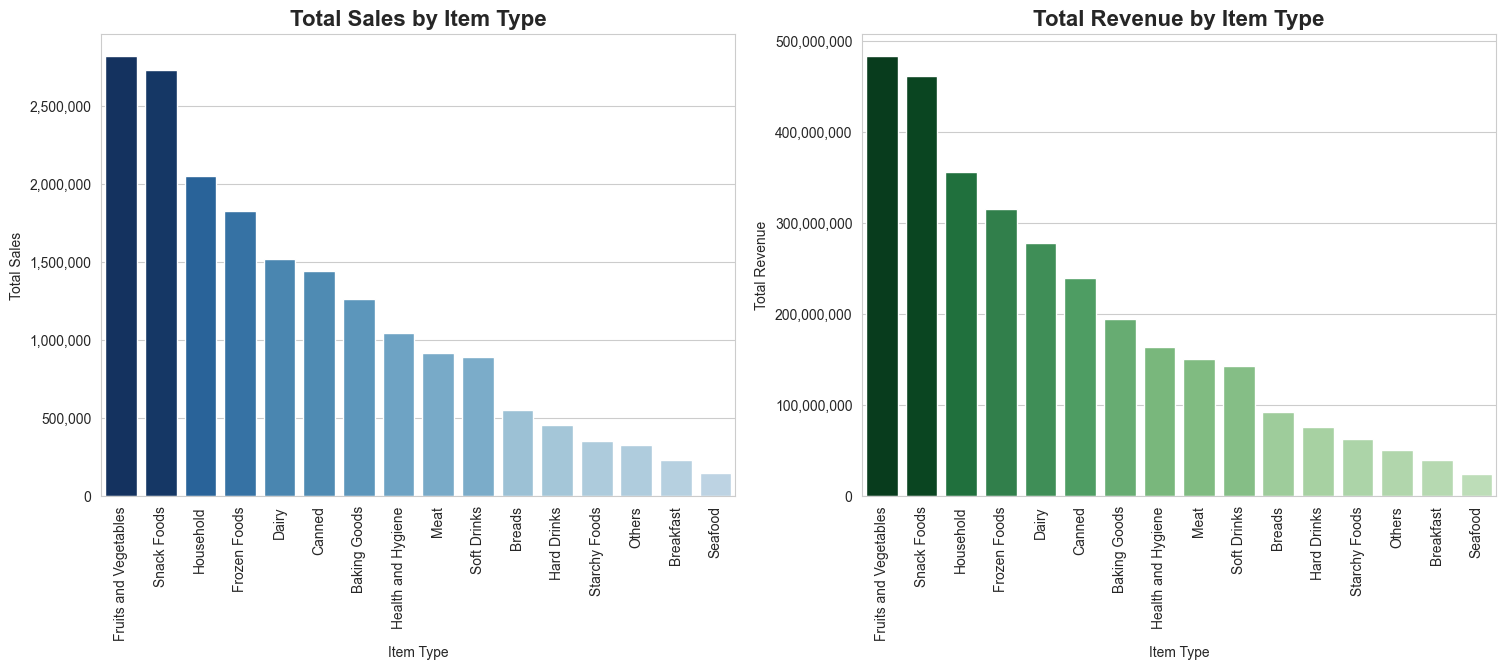

In [16]:
# Matplotlib and Seaborn visualisation of the item type with the most sales and greatest revenue
# Let's create a bar plot showing the total sales and total revenue for each item type, highlighting the top-selling and highest-revenue item types.

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

cmap_blue = plt.cm.Blues
cmap_green = plt.cm.Greens

# Compute bar colors scaled to value — higher value maps to darker shade
def value_color(series, color):
    norm = (series - series.min()) / (series.max() - series.min())
    return [color(0.3 + 0.7 * v) for v in norm]


# Total Sales by Item Type
sns.barplot(x=item_type_sales.index, y=item_type_sales.values,
            hue=item_type_sales.index, palette=value_color(item_type_sales, cmap_blue), ax=axes[0])
axes[0].set_title("Total Sales by Item Type", fontweight='bold', fontsize=16)
axes[0].tick_params(axis='x', rotation=90)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].set_xlabel("Item Type")
axes[0].set_ylabel("Total Sales")

# Total Revenue by Item Type
sns.barplot(x=item_type_revenue.index, y=item_type_revenue.values,
            hue=item_type_revenue.index, palette=value_color(item_type_revenue, cmap_green), ax=axes[1])
axes[1].set_title("Total Revenue by Item Type", fontweight='bold', fontsize=16)
axes[1].tick_params(axis='x', rotation=90)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].set_xlabel("Item Type")
axes[1].set_ylabel("Total Revenue")

plt.show()

#### Now let's add an extra step!

We are going add individual item sales and revenue values as faded points behind the bar plots. It should resemble a violin plot behind the bar plot showing the total.

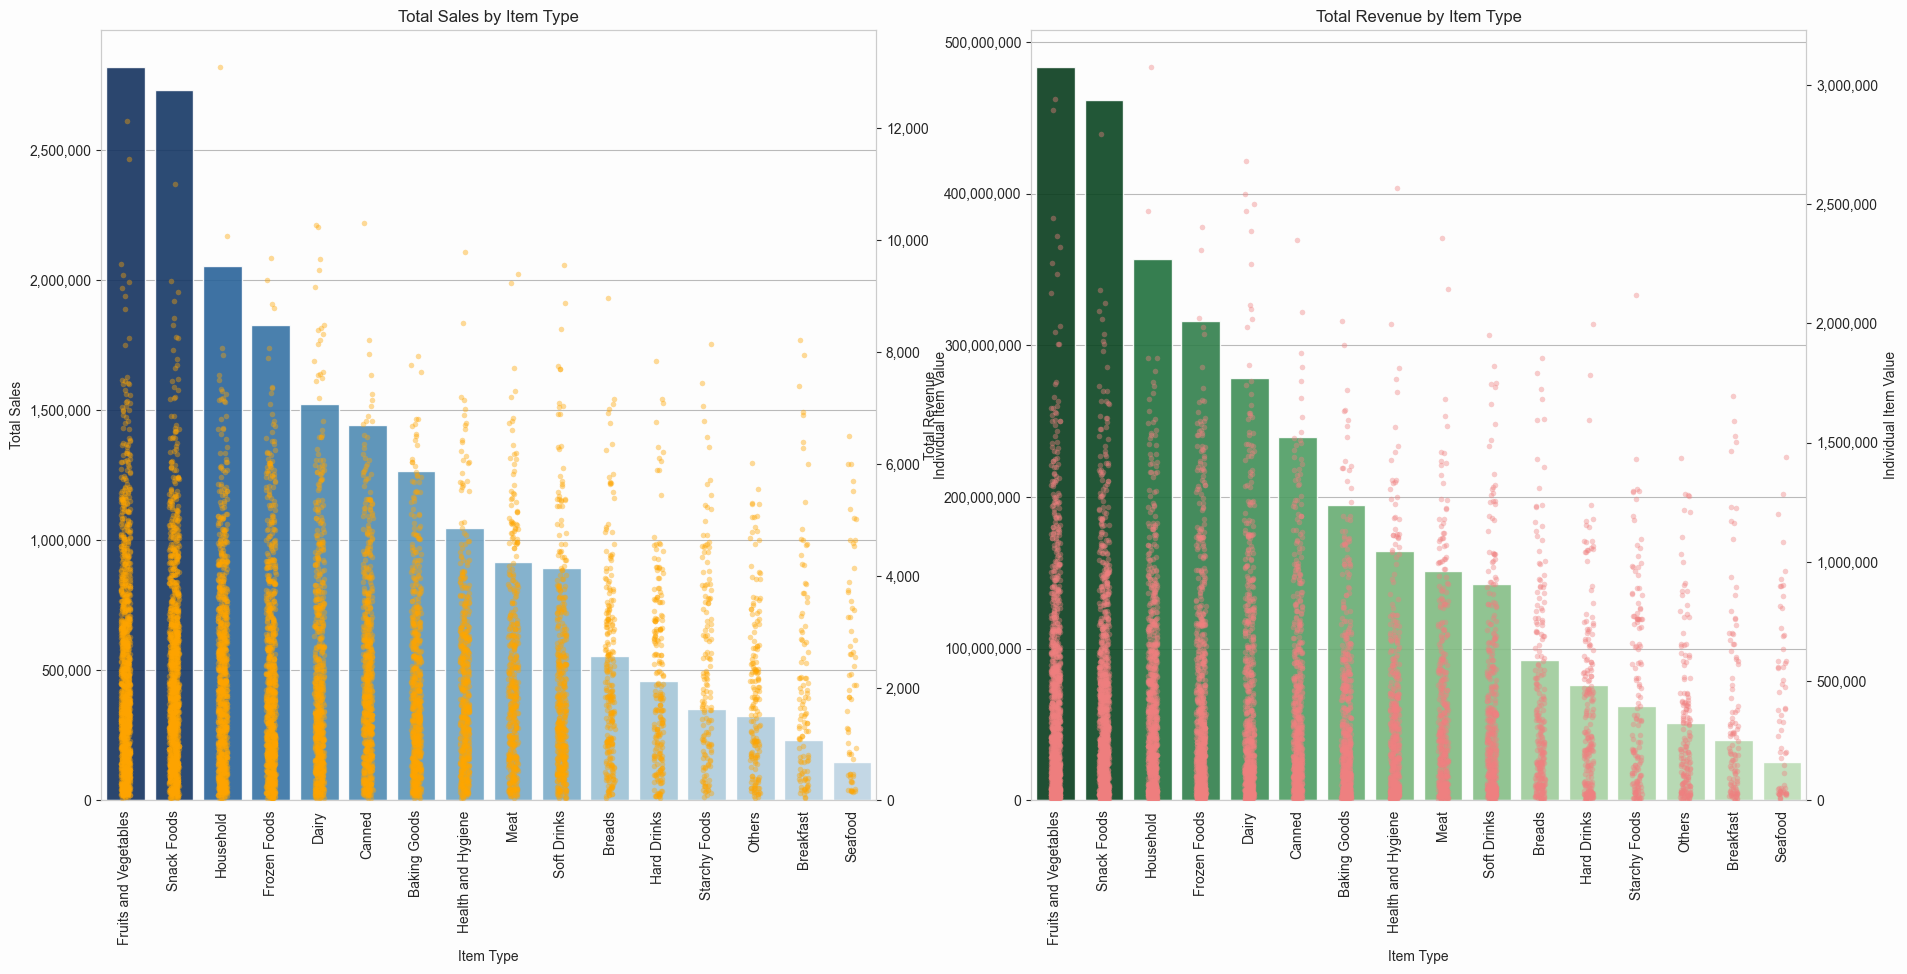

In [17]:
# Violin and bar plot combination for sales and revenue distribution by item type

sns.set_style("whitegrid", {
    "axes.facecolor": "#fdfdfd",   # plot area background
    "figure.facecolor": "#fdfdfd", # whole figure background
    "grid.color": "#BABABA"        # gridline color
})

# Bar plots of total sales and revenue per item type with individual item points on a secondary y-axis
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

cmap_blue = plt.cm.Blues
cmap_green = plt.cm.Greens

# Compute bar colors scaled to value — higher value maps to darker shade
def value_color(series, color):
    norm = (series - series.min()) / (series.max() - series.min())
    return [color(0.3 + 0.7 * v) for v in norm]

sales_totals = df_groceries.groupby('Item_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)
revenue_totals = df_groceries.groupby('Item_Type')['Revenue_per_Item'].sum().sort_values(ascending=False)

for ax, totals, color, dot_color, indiv_col, title, ylabel in [
    (axes[0], sales_totals, cmap_blue, 'orange', 'Item_Outlet_Sales', 'Total Sales by Item Type', 'Total Sales'),
    (axes[1], revenue_totals, cmap_green, 'lightcoral', 'Revenue_per_Item', 'Total Revenue by Item Type', 'Total Revenue'),
]:
    order = totals.index.tolist()

    # Left axis — total bars
    sns.barplot(x='Item_Type', y=indiv_col, data=totals.reset_index(),
                order=order, hue=totals.index, palette=value_color(totals, color), alpha=0.9,
                estimator=sum, ax=ax)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Item Type")
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylim(bottom=0)


    # Right axis — individual item points at their own scale
    ax2 = ax.twinx()
    sns.stripplot(x='Item_Type', y=indiv_col, data=df_groceries,
                  order=order, color=dot_color, alpha=0.4, size=4, ax=ax2)
    ax2.set_ylim(bottom=0)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax2.set_ylabel("Individual Item Value")
    ax2.grid(False)

plt.show()

## 4. Feature: Identify trends in outlet size, age, location, and type on sales performance

### In this section we will identify correlations and trends in outlet demographics that may link to sales performance

In [18]:
# We know there are 10 unique outlets, so let's create a summary DataFrame at the outlet level to report total sales and revenue per outlet, 
# and also include outlet-level info such as establishment year, size, location type, and type.

# Let's quickly added an Item_Revenue column to the original DataFrame for easier aggregation
df_groceries['Item_Revenue'] = df_groceries['Item_MRP'] * df_groceries['Item_Outlet_Sales']

# Aggregate total sales and revenue per outlet
outlet_totals = df_groceries.groupby('Outlet_Identifier').agg(
    Total_Sales=('Item_Outlet_Sales', 'sum'),
    Total_Revenue=('Item_Revenue', 'sum')
).reset_index()

# Merge with outlet-level info and calculate age
outlet_summary = df_outlets[['Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size_filled', 'Outlet_Location_Type', 'Outlet_Type']].merge(outlet_totals, on='Outlet_Identifier')
outlet_summary['Outlet_Age'] = 2026 - outlet_summary['Outlet_Establishment_Year']
outlet_summary = outlet_summary.sort_values('Total_Sales', ascending=False).reset_index(drop=True)

outlet_summary

,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size_filled,Outlet_Location_Type,Outlet_Type,Total_Sales,Total_Revenue,Outlet_Age
0,OUT027,1985,Medium,Tier 3,Supermarket Type3,3.453926e+06,5.733862e+08,41
1,OUT035,2004,Small,Tier 2,Supermarket Type1,2.268123e+06,3.856577e+08,22
2,OUT049,1999,Medium,Tier 1,Supermarket Type1,2.183970e+06,3.669995e+08,27
3,OUT017,2007,Small,Tier 2,Supermarket Type1,2.167465e+06,3.641322e+08,19
4,OUT013,1987,High,Tier 3,Supermarket Type1,2.142664e+06,3.664973e+08,39
5,OUT046,1997,Small,Tier 1,Supermarket Type1,2.118395e+06,3.573205e+08,29
6,OUT045,2002,Small,Tier 2,Supermarket Type1,2.036725e+06,3.432406e+08,24
7,OUT018,2009,Medium,Tier 3,Supermarket Type2,1.851823e+06,3.161732e+08,17
8,OUT010,1998,Small,Tier 3,Grocery Store,1.883402e+05,3.209849e+07,28
9,OUT019,1985,Small,Tier 1,Grocery Store,1.796941e+05,2.973453e+07,41


Great, now we just need to identify if there is any correlation between Outlet Age and Sales/Revenue. Based on our earlier exploratory analysis where we plotted Outlet age and Outlet Sales as a regression plot with Seaborn, I'm thinking it's unlikely.

In [19]:
# First let's load in the necessary libraries for statistical analysis via scipy
from scipy import stats

# Now let's calculate the pearson correlation between Outlet_Age and Total_Sales and Total_Revenue
r_sales, p_sales = stats.pearsonr(outlet_summary['Outlet_Age'], outlet_summary['Total_Sales'])
r_revenue, p_revenue = stats.pearsonr(outlet_summary['Outlet_Age'], outlet_summary['Total_Revenue'])

print(f"Outlet Age vs Total Sales:   r = {r_sales:.3f},  p = {p_sales:.3f}")
print(f"Outlet Age vs Total Revenue: r = {r_revenue:.3f},  p = {p_revenue:.3f}")

Outlet Age vs Total Sales:   r = -0.050,  p = 0.892
Outlet Age vs Total Revenue: r = -0.059,  p = 0.872


We see that, as expected there is no correlation between outlet age and sales or revenue! Let's also visualise this in more detail compared to what we did earlier.

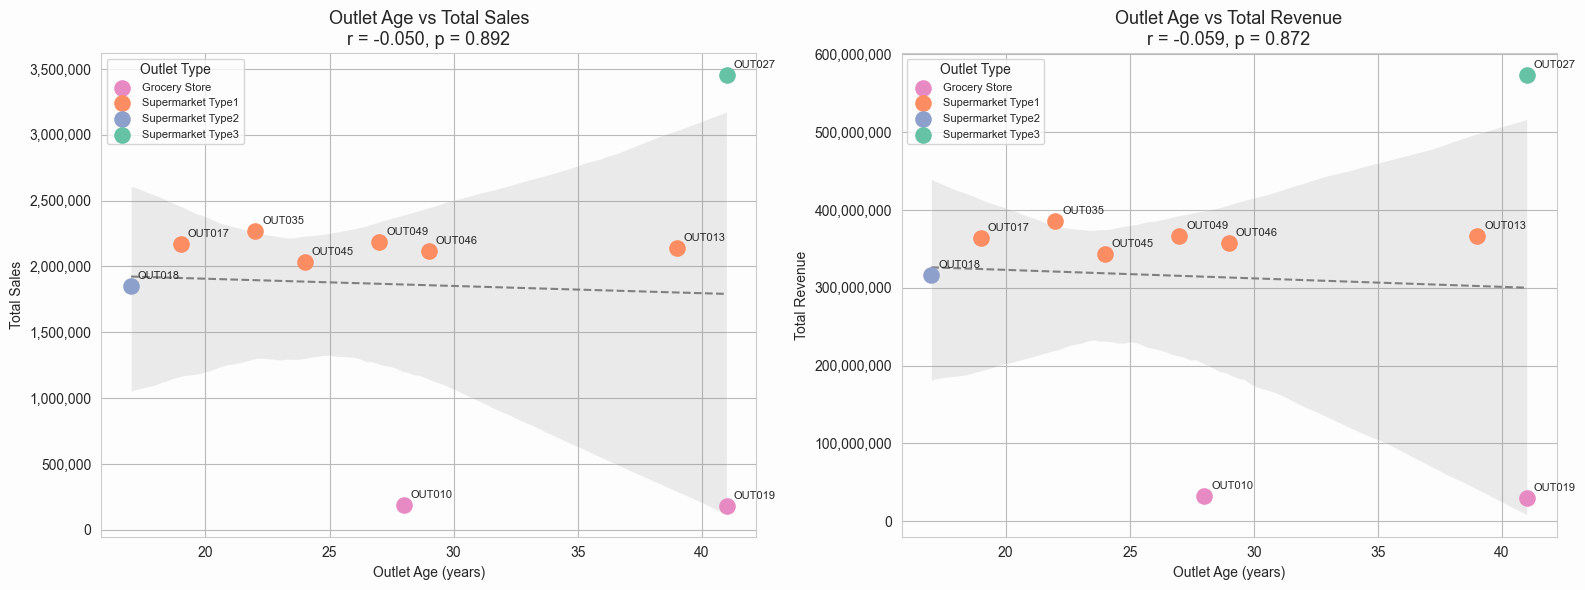

In [20]:
# Scatter + regression plots coloured by Outlet_Type to surface any confounding effect
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

outlet_types = outlet_summary['Outlet_Type'].unique()
palette = dict(zip(outlet_types, sns.color_palette('Set2', len(outlet_types))))

for ax, y_col, title, ylabel, r, p in [
    (axes[0], 'Total_Sales',   'Outlet Age vs Total Sales',   'Total Sales',   r_sales,   p_sales),
    (axes[1], 'Total_Revenue', 'Outlet Age vs Total Revenue', 'Total Revenue', r_revenue, p_revenue),
]:
    # Regression line across all outlets
    sns.regplot(x='Outlet_Age', y=y_col, data=outlet_summary,
                scatter=False, color='gray', line_kws={'linestyle': '--', 'linewidth': 1.5}, ax=ax)

    # Points coloured by outlet type
    for otype, group in outlet_summary.groupby('Outlet_Type'):
        ax.scatter(group['Outlet_Age'], group[y_col],
                   label=otype, color=palette[otype], s=120, zorder=5)
        for _, row in group.iterrows():
            ax.annotate(row['Outlet_Identifier'],
                        xy=(row['Outlet_Age'], row[y_col]),
                        xytext=(5, 5), textcoords='offset points', fontsize=8)

    ax.set_title(f"{title}\nr = {r:.3f}, p = {p:.3f}", fontsize=13)
    ax.set_xlabel("Outlet Age (years)")
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(title='Outlet Type', fontsize=8)

plt.tight_layout()
plt.show()

## 5. Machine Learning: Regression modeling to predict future sales performance

### In this section we will implement basic machine learning and statistical techniques to predict future sales performance.

#### Step 1 is preparing the features. The item fat content is inconsistent in the wording used. We also need to 

In [27]:
# First we need to import the necessary libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Normalise inconsistent Item_Fat_Content labels (e.g. 'LF' vs 'Low Fat', 'reg' vs 'Regular') by mapping to consistent values
fat_map = {'lf': 'low fat', 'Low Fat': 'Low Fat', 'Regular': 'reg'}
df_groceries['Item_Fat_Content'] = df_groceries['Item_Fat_Content'].str.lower().replace(fat_map)

# Select features — Used the filled versions of Item Weight and Outlet Size, and the new feature Outlet_Age
# exclude identifiers and any revenue/sales-derived columns to prevent leakage
features = [
    'Item_MRP', 'Item_Visibility', 'Outlet_Type', 'Item_Type'
]


# features = [
#     'Item_Weight_filled', 'Item_Visibility', 'Item_MRP', 'Outlet_Age',
#     'Item_Fat_Content', 'Item_Type', 'Outlet_Size_filled',
#     'Outlet_Location_Type', 'Outlet_Type'
# ]

# One-hot encode categorical features; drop_first avoids multicollinearity and makes sure the system of equations is solvable
X = pd.get_dummies(df_groceries[features], drop_first=True)
y = df_groceries['Item_Outlet_Sales']


In [28]:
# Train / test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Features         : {X_train.shape[1]}")


Training samples : 6818
Test samples     : 1705
Features         : 20


In [29]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Model Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model Coefficients: [  15.6544551  -450.87977107 1955.95841363 1621.77292547 3344.45229266
  -29.08062529   79.41072513   24.73679306  -93.90348827  -12.32481754
   42.716278    -16.40300187   -9.88100043  -39.56736566    7.18243395
  -73.88737399  221.80159319  -11.0741884   -44.89746646   21.05528523]
Intercept: -1808.1774551975986


In [30]:
# Evaluate model performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:,.2f}")
print(f"MAE  : {mae:,.2f}")
print(f"R²   : {r2:.4f}")


RMSE : 1,070.73
MAE  : 792.87
R²   : 0.5782


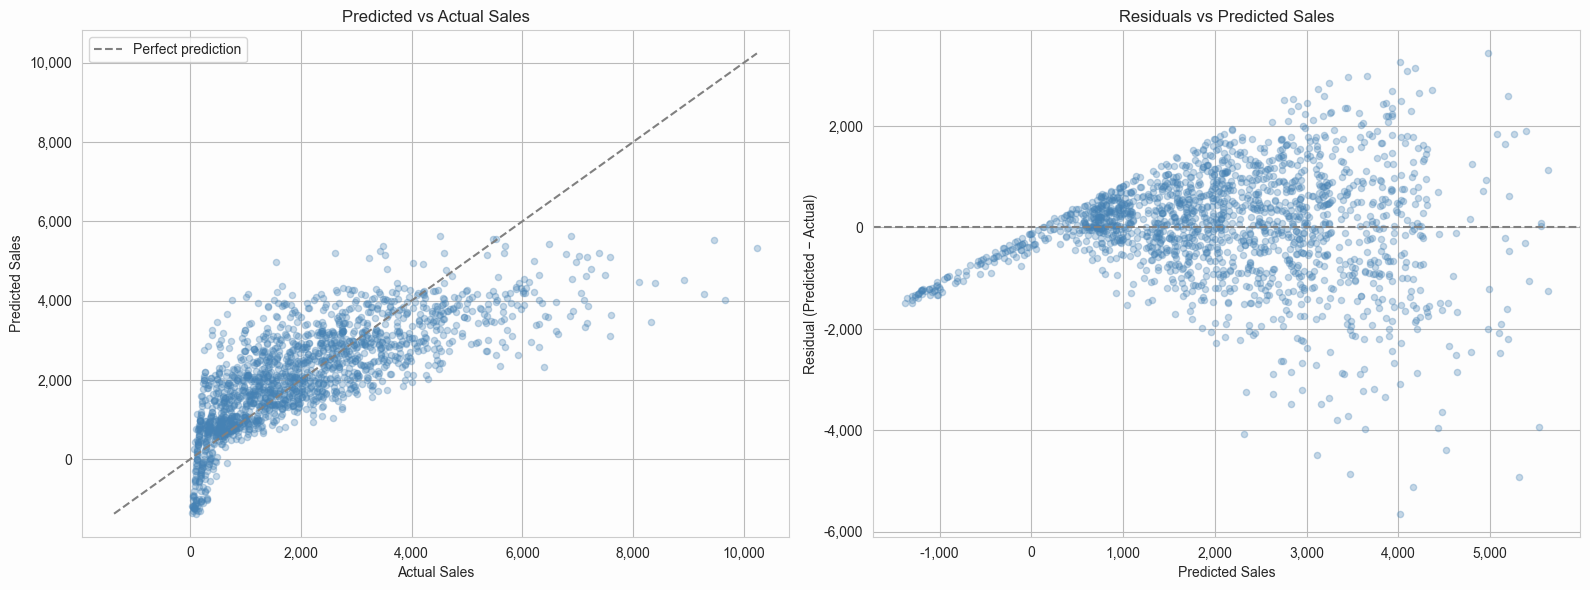

In [31]:
# Visualise model predictions and residuals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.3, s=20, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, '--', color='gray', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel("Actual Sales")
axes[0].set_ylabel("Predicted Sales")
axes[0].set_title("Predicted vs Actual Sales")
axes[0].legend()
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Residuals vs Predicted
residuals = y_pred - y_test
axes[1].scatter(y_pred, residuals, alpha=0.3, s=20, color='steelblue')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1.5)
axes[1].set_xlabel("Predicted Sales")
axes[1].set_ylabel("Residual (Predicted − Actual)")
axes[1].set_title("Residuals vs Predicted Sales")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()


In [ ]:
results = pd.DataFrame({
    "Product_ID": df_groceries.loc[X_test.index, "Item_Identifier"],
    "Actual_Sales": y_test,
    "Predicted_Sales": y_pred
})

results.head(10)

,Product_ID,Actual_Sales,Predicted_Sales
7503,FDI28,1743.0644,1410.025250
2957,NCM17,356.8688,639.386153
7031,FDC14,377.5086,762.366364
1084,DRC36,5778.4782,2791.530227
856,FDS27,2356.9320,3305.617535
4304,DRK12,865.5400,611.124534
2132,FDO25,4613.9940,2973.300412
1385,FDB58,2410.8618,2438.908264
5239,FDY48,1948.1308,1789.149045
6516,NCP42,1937.4780,3205.702927
